<a href="https://colab.research.google.com/github/anzuyadav/Costume-Rental-Shop/blob/main/Task2_Regression_Simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Regression: Student Performance Prediction

**Dataset:** Student Performance Dataset (UCI / Kaggle)  
**Dataset Link:** https://www.kaggle.com/datasets/larsen0966/student-performance-data-set  
**Models:** Linear Regression + Deep Neural Network (DNN)  
**Target Variable:** G3 (Final Grade, 0–20)  
**Metrics:** MSE, RMSE, R² Score, MAPE

---
## Step 1: Install and Import Libraries

In [3]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import LinearRegression from sklearn
from sklearn.linear_model import LinearRegression

# Import train_test_split — splits data into training and testing
from sklearn.model_selection import train_test_split

# Import StandardScaler — scales features to same range
from sklearn.preprocessing import StandardScaler

# Import LabelEncoder — converts text columns to numbers
from sklearn.preprocessing import LabelEncoder

# Import metrics — to measure model performance
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error

# Import tensorflow and keras — used to build the Neural Network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2: Load the Dataset

No download needed — loads automatically from a public URL!

In [4]:
# Load the Maths student dataset from public URL
url_math = 'https://raw.githubusercontent.com/arunk13/MSDA-Assignments/master/IS607Fall2015/Assignment3/student-mat.csv'
df_math = pd.read_csv(url_math, sep=';')

# Load the Portuguese student dataset from public URL
url_por = 'https://raw.githubusercontent.com/arunk13/MSDA-Assignments/master/IS607Fall2015/Assignment3/student-por.csv'
df_por = pd.read_csv(url_por, sep=';')

# Combine both datasets into one
df = pd.concat([df_math, df_por], ignore_index=True)


# Print basic info
print('Dataset loaded successfully!')
print('Number of rows    :', df.shape[0])
print('Number of columns :', df.shape[1])
print('Target variable   : G3 (Final Grade)')
print()

# Show first 5 rows
df.head()

Dataset loaded successfully!
Number of rows    : 1044
Number of columns : 33
Target variable   : G3 (Final Grade)



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


---
## Step 3: Explore the Dataset

In [5]:
# Show all column names
print('Column names:')
print(df.columns.tolist())

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [6]:
# Show data types of each column
print('Data types:')
print(df.dtypes)

Data types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [7]:
# Check for missing values
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [8]:
# Show basic statistics of the dataset
print('Basic statistics:')
df.describe()

Basic statistics:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [9]:
# Show statistics of the target variable G3
print('Target Variable — G3 (Final Grade) Statistics:')
print('Minimum  :', df['G3'].min())
print('Maximum  :', df['G3'].max())
print('Average  :', round(df['G3'].mean(), 2))
print('Median   :', df['G3'].median())

Target Variable — G3 (Final Grade) Statistics:
Minimum  : 0
Maximum  : 20
Average  : 11.34
Median   : 11.0


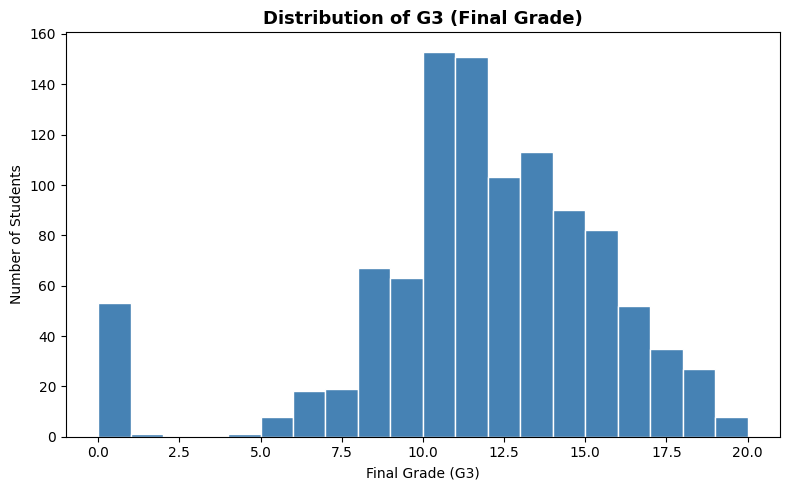

In [10]:
# Plot the distribution of G3 (target variable)
plt.figure(figsize=(8, 5))
plt.hist(df['G3'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of G3 (Final Grade)', fontsize=13, fontweight='bold')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

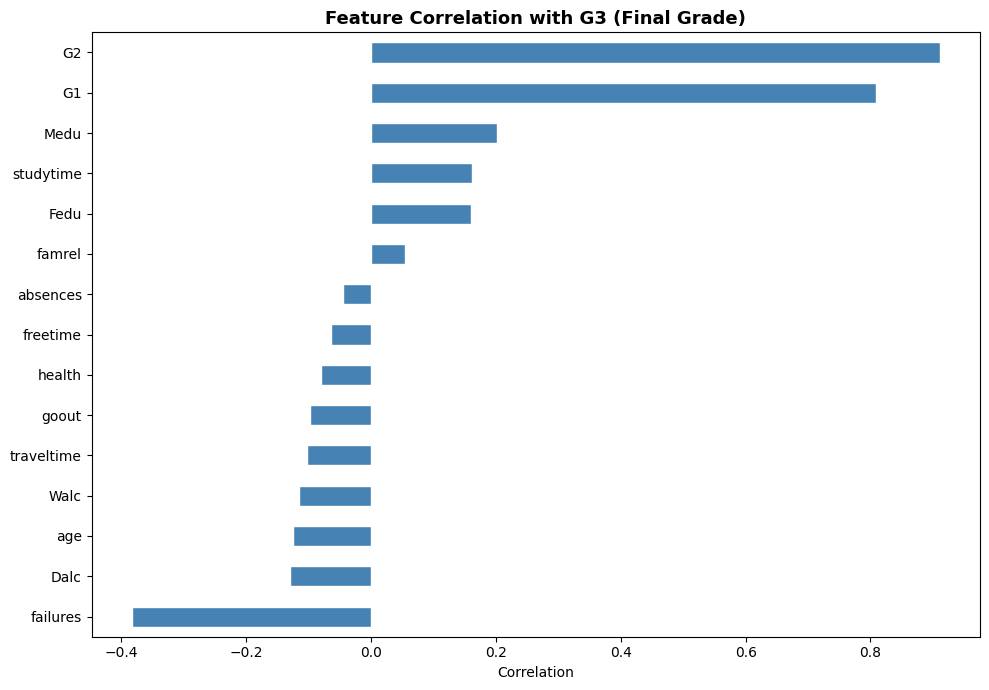

In [11]:
# Plot correlation of numeric features with G3
# Get only numeric columns
numeric_cols = df.select_dtypes(include=[np.number])

# Calculate correlation with G3
corr = numeric_cols.corr()['G3'].drop('G3').sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 7))
corr.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Correlation with G3 (Final Grade)', fontsize=13, fontweight='bold')
plt.xlabel('Correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

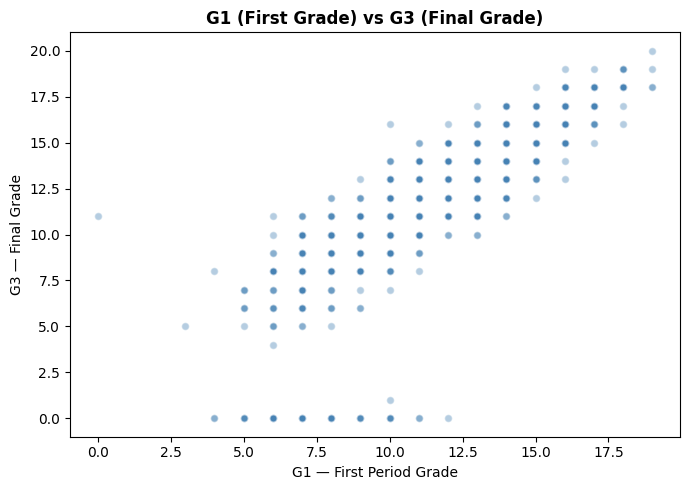

In [12]:
# Plot G1 vs G3 (first grade vs final grade)
plt.figure(figsize=(7, 5))
plt.scatter(df['G1'], df['G3'], alpha=0.4, color='steelblue', edgecolors='white', s=30)
plt.title('G1 (First Grade) vs G3 (Final Grade)', fontsize=12, fontweight='bold')
plt.xlabel('G1 — First Period Grade')
plt.ylabel('G3 — Final Grade')
plt.tight_layout()
plt.show()

---
## Step 4: Preprocess the Data

In [13]:
# Separate features (X) and target (y)
X = df.drop(columns=['G3'])   # all columns except G3
y = df['G3']                  # G3 is what we want to predict

print('Features shape :', X.shape)
print('Target shape   :', y.shape)

Features shape : (1044, 32)
Target shape   : (1044,)


In [14]:
# Convert all text columns to numbers using LabelEncoder
# Models only understand numbers — not text like 'yes', 'no', 'GP'

le = LabelEncoder()

# Go through each column
for col in X.columns:
    # If the column has text values
    if X[col].dtype == 'object':
        # Convert text to numbers
        X[col] = le.fit_transform(X[col])

print('All text columns converted to numbers!')
print()
X.head()

All text columns converted to numbers!



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2
0,0,0,18,1,0,0,4,4,0,4,...,0,4,3,4,1,1,3,6,5,6
1,0,0,17,1,0,1,1,1,0,2,...,0,5,3,3,1,1,3,4,5,5
2,0,0,15,1,1,1,1,1,0,2,...,0,4,3,2,2,3,3,10,7,8
3,0,0,15,1,0,1,4,2,1,3,...,1,3,2,2,1,1,5,2,15,14
4,0,0,16,1,0,1,3,3,2,2,...,0,4,3,2,1,2,5,4,6,10


In [15]:
# Split data into training set and testing set
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% goes to testing
    random_state=42    # fixed so results are same every run
)

print('Training samples :', X_train.shape[0])
print('Testing  samples :', X_test.shape[0])

Training samples : 835
Testing  samples : 209


In [16]:
# Scale all features using StandardScaler
# This makes all numbers have the same scale (mean=0, std=1)
# Important so that no single feature dominates the model

scaler = StandardScaler()

# Learn the scale from training data and apply it
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scale to test data (do NOT fit again on test data)
X_test_scaled = scaler.transform(X_test)

print('Features scaled using StandardScaler!')
print('This is Optimisation Technique 1 — StandardScaler')

Features scaled using StandardScaler!
This is Optimisation Technique 1 — StandardScaler


---
## Step 5: Model 1 — Linear Regression

In [17]:
# Create the Linear Regression model
lr = LinearRegression()

# Train the model on training data
lr.fit(X_train_scaled, y_train)

print('Linear Regression model trained!')

Linear Regression model trained!


In [18]:
# Make predictions on the test set
lr_predictions = lr.predict(X_test_scaled)

print('Predictions made on test set!')
print('First 5 predicted grades :', lr_predictions[:5].round(2))
print('First 5 actual grades    :', y_test.values[:5])

Predictions made on test set!
First 5 predicted grades : [10.49  8.17 14.22 11.13 12.04]
First 5 actual grades    : [11  8 13 11 12]


In [19]:
# Calculate evaluation metrics for Linear Regression

# MSE — Mean Squared Error (lower is better)
lr_mse = mean_squared_error(y_test, lr_predictions)

# RMSE — Root Mean Squared Error (lower is better, same unit as grade)
lr_rmse = np.sqrt(lr_mse)

# R2 Score — how well model explains the data (closer to 1 = better)
lr_r2 = r2_score(y_test, lr_predictions)

# MAPE — Mean Absolute Percentage Error (lower is better)
lr_mape = mean_absolute_percentage_error(y_test, lr_predictions) * 100

# Print results
print('================================================')
print('   Linear Regression — Results')
print('================================================')
print('MSE      :', round(lr_mse,  4), '  (lower is better)')
print('RMSE     :', round(lr_rmse, 4), '  (lower is better)')
print('R2 Score :', round(lr_r2,   4), '  (closer to 1 = better)')
print('MAPE     :', round(lr_mape, 4), '% (lower is better)')
print('================================================')

   Linear Regression — Results
MSE      : 3.1514   (lower is better)
RMSE     : 1.7752   (lower is better)
R2 Score : 0.7962   (closer to 1 = better)
MAPE     : 1.0622220456228506e+17 % (lower is better)


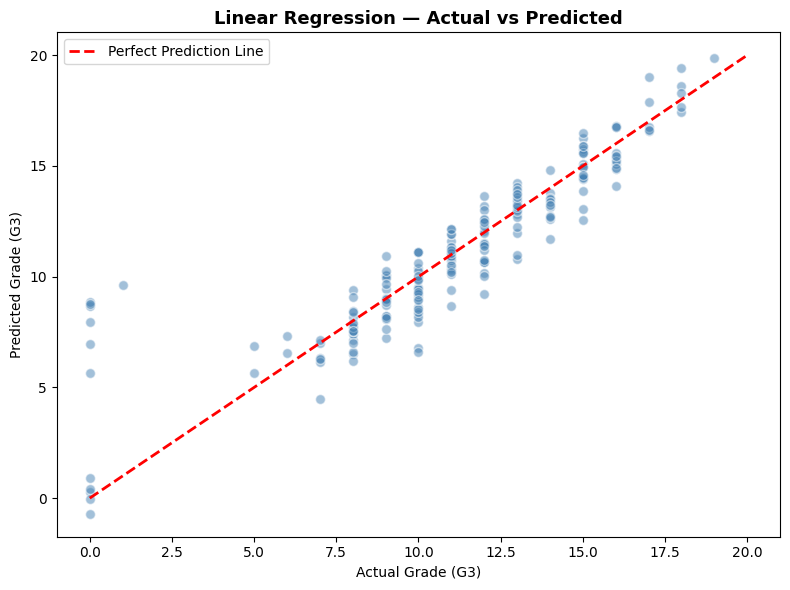

In [20]:
# Plot Actual vs Predicted for Linear Regression
plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted values
plt.scatter(y_test, lr_predictions,
            alpha=0.5, color='steelblue', edgecolors='white', s=50)

# Red dashed line = perfect prediction line
plt.plot([0, 20], [0, 20], 'r--', linewidth=2, label='Perfect Prediction Line')

plt.xlabel('Actual Grade (G3)')
plt.ylabel('Predicted Grade (G3)')
plt.title('Linear Regression — Actual vs Predicted', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

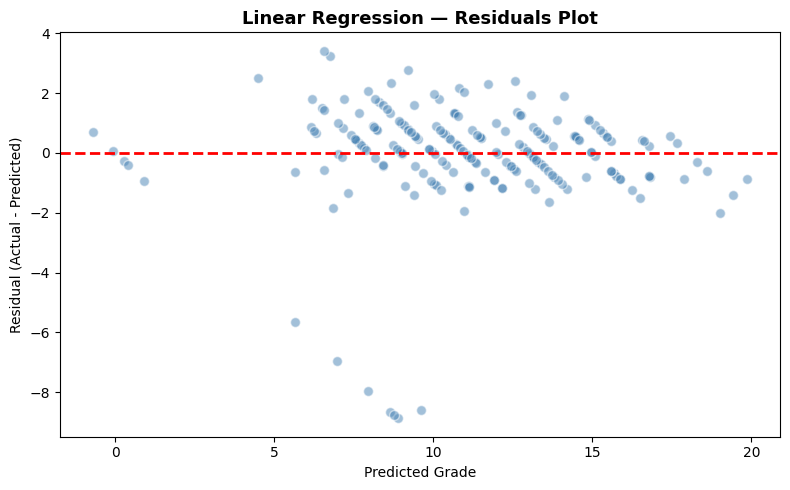

In [21]:
# Plot Residuals for Linear Regression
# Residuals = actual grade minus predicted grade

lr_residuals = y_test.values - lr_predictions

plt.figure(figsize=(8, 5))
plt.scatter(lr_predictions, lr_residuals,
            alpha=0.5, color='steelblue', edgecolors='white', s=50)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Grade')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Linear Regression — Residuals Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 6: Model 2 — Deep Neural Network (DNN)

In [22]:
# Set random seed so results are the same every time
tf.random.set_seed(42)
np.random.seed(42)

# Build the DNN model layer by layer
dnn = keras.Sequential()

# Input layer — number of features we have
dnn.add(layers.Input(shape=(X_train_scaled.shape[1],)))

# Hidden layer 1 — 128 neurons, relu activation
dnn.add(layers.Dense(128, activation='relu'))

# Batch Normalisation — stabilises training (Optimisation Technique 2)
dnn.add(layers.BatchNormalization())

# Dropout — randomly turns off 30% neurons to prevent overfitting (Optimisation Technique 3)
dnn.add(layers.Dropout(0.3))

# Hidden layer 2 — 64 neurons
dnn.add(layers.Dense(64, activation='relu'))

# Batch Normalisation again
dnn.add(layers.BatchNormalization())

# Dropout again
dnn.add(layers.Dropout(0.2))

# Hidden layer 3 — 32 neurons
dnn.add(layers.Dense(32, activation='relu'))

# Output layer — 1 neuron (we predict a single grade value)
dnn.add(layers.Dense(1, activation='linear'))

# Compile the model
# Adam optimiser = smart learning rate (Optimisation Technique 4)
# loss = mse because this is a regression problem
dnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print('DNN model built successfully!')
print()
dnn.summary()

DNN model built successfully!



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,361 (60.00 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [23]:
# Set up EarlyStopping
# This stops training automatically when the model stops improving
# This is Optimisation Technique 5

early_stop = EarlyStopping(
    monitor='val_loss',         # watch the validation loss
    patience=15,                # stop after 15 epochs with no improvement
    restore_best_weights=True,  # keep the best model weights
    verbose=1
)

print('EarlyStopping callback ready!')

EarlyStopping callback ready!


In [24]:
# Train the DNN model
print('Training DNN... please wait...')
print()

history = dnn.fit(
    X_train_scaled, y_train,
    validation_split=0.2,   # use 20% of training data for validation
    epochs=150,             # maximum 150 training rounds
    batch_size=32,          # process 32 samples at a time
    callbacks=[early_stop], # use early stopping
    verbose=1
)

print()
print('DNN training complete!')
print('Stopped at epoch:', len(history.history['loss']))

Training DNN... please wait...

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 135.2502 - mae: 11.0360 - val_loss: 134.5500 - val_mae: 10.9243
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 105.8299 - mae: 9.7740 - val_loss: 120.7843 - val_mae: 10.3903
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 76.4494 - mae: 8.3009 - val_loss: 100.3097 - val_mae: 9.5203
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 48.2148 - mae: 6.4433 - val_loss: 75.0161 - val_mae: 8.2659
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 29.5919 - mae: 4.7773 - val_loss: 52.2638 - val_mae: 6.8894
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 17.2824 - mae: 3.5137 - val_loss: 35.0976 - val_mae: 5.6001
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12.5025 - mae: 2.8592 - val_loss: 24.2920 - val_mae: 4.6059
Epoch 8/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.4838 - mae: 2.4707 - val_loss: 17.9841 - val_mae: 3.9110
Epoch 9/

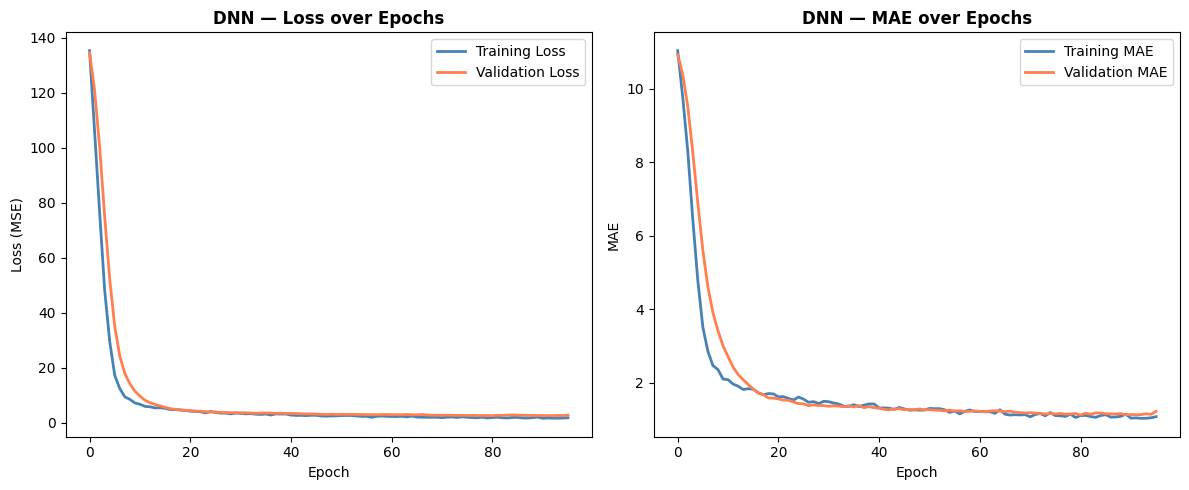

In [25]:
# Plot Training History — Loss over epochs
plt.figure(figsize=(12, 5))

# Plot 1 — Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='coral',     linewidth=2)
plt.title('DNN — Loss over Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# Plot 2 — MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'],     label='Training MAE',   color='steelblue', linewidth=2)
plt.plot(history.history['val_mae'], label='Validation MAE', color='coral',     linewidth=2)
plt.title('DNN — MAE over Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
# Make predictions using the DNN
dnn_predictions = dnn.predict(X_test_scaled).flatten()

print('DNN predictions made!')
print('First 5 predicted grades :', dnn_predictions[:5].round(2))
print('First 5 actual grades    :', y_test.values[:5])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
DNN predictions made!
First 5 predicted grades : [ 9.6   7.74 13.96 12.33 13.1 ]
First 5 actual grades    : [11  8 13 11 12]


In [27]:
# Calculate evaluation metrics for DNN

# MSE
dnn_mse = mean_squared_error(y_test, dnn_predictions)

# RMSE
dnn_rmse = np.sqrt(dnn_mse)

# R2 Score
dnn_r2 = r2_score(y_test, dnn_predictions)

# MAPE
dnn_mape = mean_absolute_percentage_error(y_test, dnn_predictions) * 100

# Print results
print('================================================')
print('   Deep Neural Network — Results')
print('================================================')
print('MSE      :', round(dnn_mse,  4), '  (lower is better)')
print('RMSE     :', round(dnn_rmse, 4), '  (lower is better)')
print('R2 Score :', round(dnn_r2,   4), '  (closer to 1 = better)')
print('MAPE     :', round(dnn_mape, 4), '% (lower is better)')
print('================================================')

   Deep Neural Network — Results
MSE      : 4.3093   (lower is better)
RMSE     : 2.0759   (lower is better)
R2 Score : 0.7213   (closer to 1 = better)
MAPE     : 1.116761827049472e+17 % (lower is better)


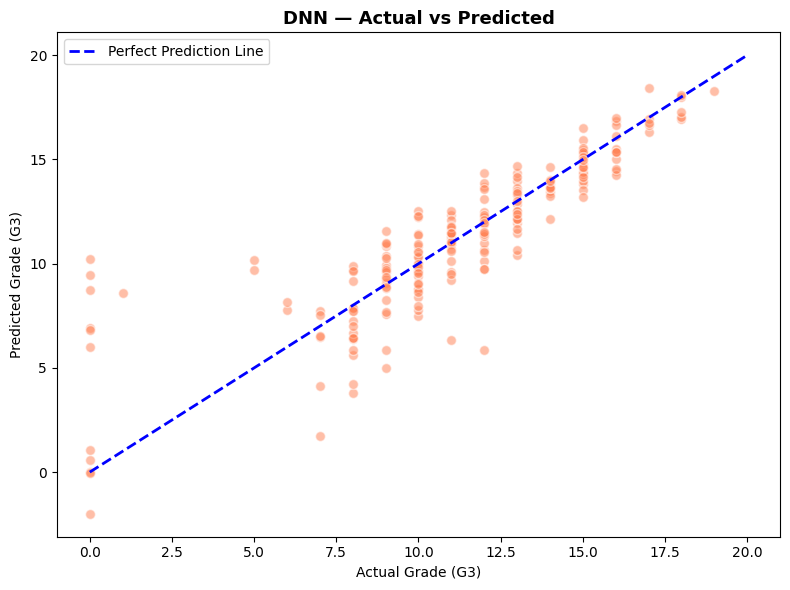

In [28]:
# Plot Actual vs Predicted for DNN
plt.figure(figsize=(8, 6))

plt.scatter(y_test, dnn_predictions,
            alpha=0.5, color='coral', edgecolors='white', s=50)

plt.plot([0, 20], [0, 20], 'b--', linewidth=2, label='Perfect Prediction Line')

plt.xlabel('Actual Grade (G3)')
plt.ylabel('Predicted Grade (G3)')
plt.title('DNN — Actual vs Predicted', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

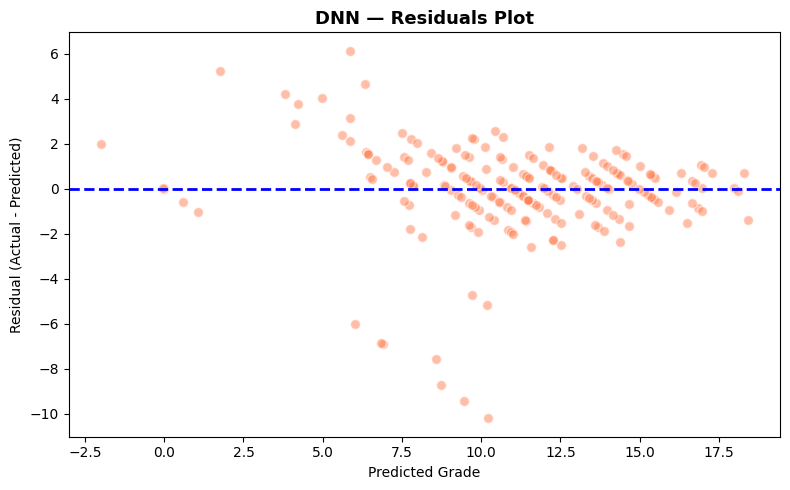

In [29]:
# Plot Residuals for DNN
dnn_residuals = y_test.values - dnn_predictions

plt.figure(figsize=(8, 5))
plt.scatter(dnn_predictions, dnn_residuals,
            alpha=0.5, color='coral', edgecolors='white', s=50)
plt.axhline(y=0, color='blue', linestyle='--', linewidth=2)
plt.xlabel('Predicted Grade')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('DNN — Residuals Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 7: Final Comparison — Both Models

In [30]:
# Print final comparison table
print('=======================================================')
print('   FINAL RESULTS — MODEL COMPARISON')
print('=======================================================')
print(f'{'Metric':<15} {'Linear Regression':>20} {'DNN':>20}')
print('-------------------------------------------------------')
print(f'{'MSE':<15} {round(lr_mse, 4):>20} {round(dnn_mse, 4):>20}')
print(f'{'RMSE':<15} {round(lr_rmse, 4):>20} {round(dnn_rmse, 4):>20}')
print(f'{'R2 Score':<15} {round(lr_r2, 4):>20} {round(dnn_r2, 4):>20}')
print(f'{'MAPE (%)':<15} {round(lr_mape, 4):>20} {round(dnn_mape, 4):>20}')
print('=======================================================')

   FINAL RESULTS — MODEL COMPARISON
Metric             Linear Regression                  DNN
-------------------------------------------------------
MSE                           3.1514               4.3093
RMSE                          1.7752               2.0759
R2 Score                      0.7962               0.7213
MAPE (%)        1.0622220456228506e+17 1.116761827049472e+17


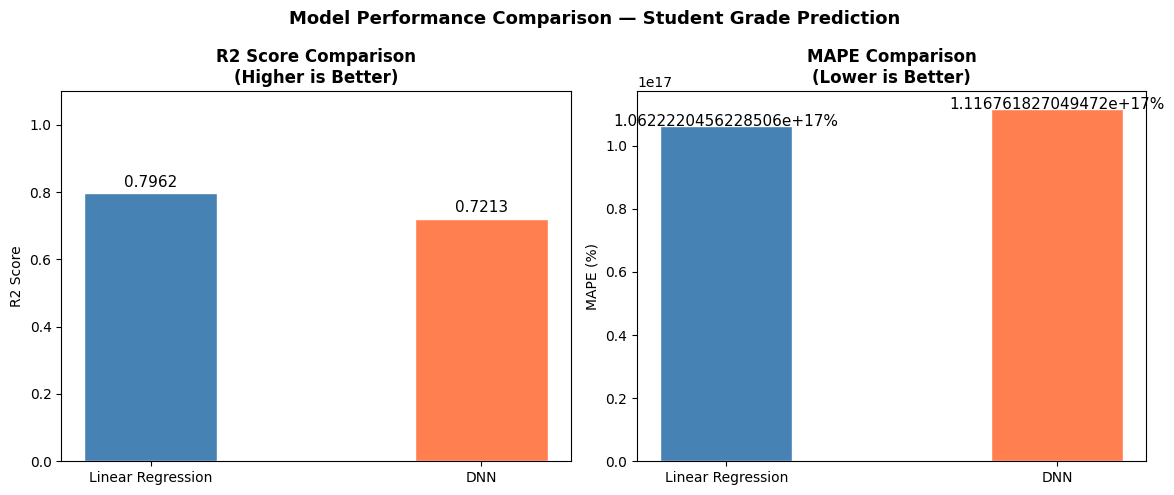

In [31]:
# Bar chart comparison — R2 Score
plt.figure(figsize=(12, 5))

# Plot 1 — R2 Score comparison
plt.subplot(1, 2, 1)
models = ['Linear Regression', 'DNN']
r2_values = [round(lr_r2, 4), round(dnn_r2, 4)]
bars = plt.bar(models, r2_values, color=['steelblue', 'coral'], edgecolor='white', width=0.4)
plt.title('R2 Score Comparison\n(Higher is Better)', fontsize=12, fontweight='bold')
plt.ylabel('R2 Score')
plt.ylim(0, 1.1)
# Add value labels on bars
for bar, val in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             str(val), ha='center', fontsize=11)

# Plot 2 — MAPE comparison
plt.subplot(1, 2, 2)
mape_values = [round(lr_mape, 4), round(dnn_mape, 4)]
bars2 = plt.bar(models, mape_values, color=['steelblue', 'coral'], edgecolor='white', width=0.4)
plt.title('MAPE Comparison\n(Lower is Better)', fontsize=12, fontweight='bold')
plt.ylabel('MAPE (%)')
# Add value labels on bars
for bar, val in zip(bars2, mape_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val) + '%', ha='center', fontsize=11)

plt.suptitle('Model Performance Comparison — Student Grade Prediction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

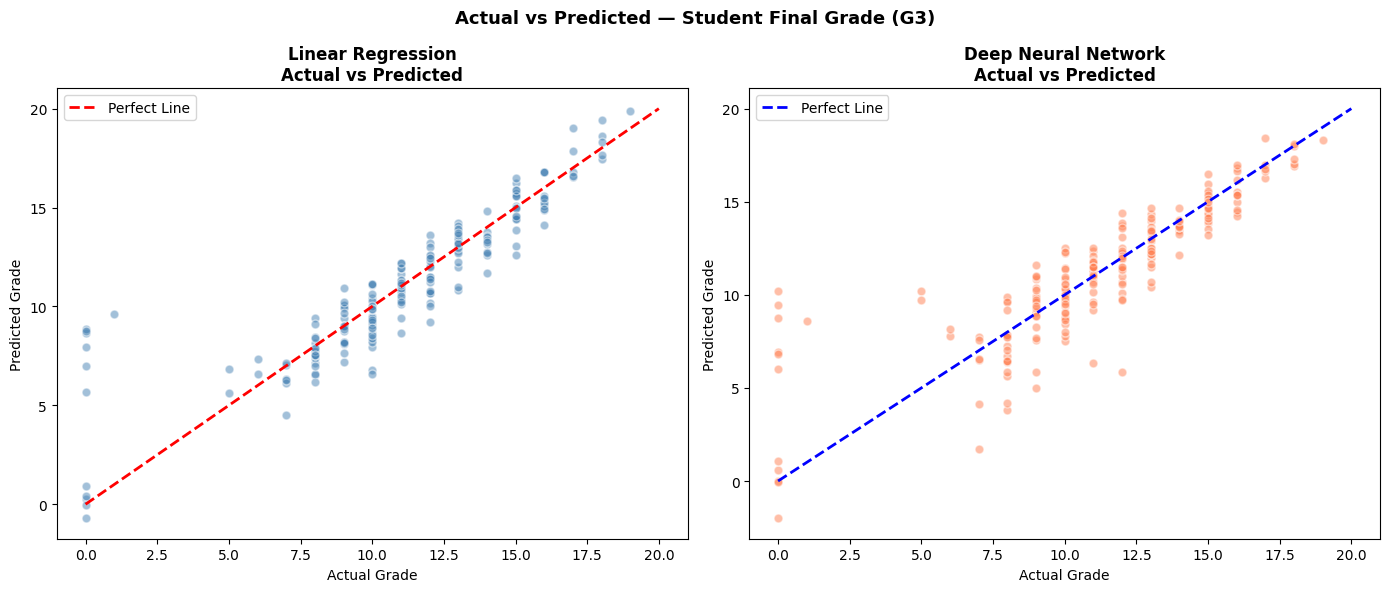

In [32]:
# Side by side Actual vs Predicted for both models
plt.figure(figsize=(14, 6))

# Linear Regression plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_predictions,
            alpha=0.5, color='steelblue', edgecolors='white', s=40)
plt.plot([0, 20], [0, 20], 'r--', linewidth=2, label='Perfect Line')
plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')
plt.title('Linear Regression\nActual vs Predicted', fontweight='bold')
plt.legend()

# DNN plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, dnn_predictions,
            alpha=0.5, color='coral', edgecolors='white', s=40)
plt.plot([0, 20], [0, 20], 'b--', linewidth=2, label='Perfect Line')
plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')
plt.title('Deep Neural Network\nActual vs Predicted', fontweight='bold')
plt.legend()

plt.suptitle('Actual vs Predicted — Student Final Grade (G3)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

